## Cell 1: Imports + Device

**What:** Import the libraries and choose the training device.

**Why:** This sets up every dependency we need before any data or model work starts.

**Cons:** More imports increase setup complexity and can fail if any package is missing.


In [1]:
# ── Cell 1: Imports + Device ──────────────────────────────────
import copy, json
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device : {device}")

PyTorch: 2.5.1+cu121
Device : cuda


## Cell 2: Transforms

**What:** Define the image transforms for training and validation.

**Why:** We standardize inputs and add augmentation so the model can generalize better.

**Cons:** Heavy augmentation can sometimes distort important disease patterns.


In [2]:
# ── Cell 2: Transforms ───────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

print("✅ Transforms ready")

✅ Transforms ready


## Cell 3: Dataset Loading

**What:** Load the maize dataset and split it into train, validation, and test sets.

**Why:** This gives us clean partitions for learning, tuning, and final evaluation.

**Cons:** A random split can still introduce mild class imbalance or sample bias.


In [3]:
# ── Cell 3: Dataset Loading ───────────────────────────────────
DATASET_PATH = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/maize"  # change this

full_dataset = ImageFolder(DATASET_PATH)
class_names  = full_dataset.classes
NUM_CLASSES  = len(class_names)

print(f"✅ Classes ({NUM_CLASSES}): {class_names}")
print(f"✅ Total images: {len(full_dataset)}")

# 70/15/15 split
n       = len(full_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_indices, val_indices, test_indices = random_split(
    range(n), [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Independent datasets prevent validation transforms from leaking into training.
train_ds = Subset(ImageFolder(DATASET_PATH, transform=train_transform), train_indices.indices)
val_ds   = Subset(ImageFolder(DATASET_PATH, transform=val_transform), val_indices.indices)
test_ds  = Subset(ImageFolder(DATASET_PATH, transform=val_transform), test_indices.indices)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")

with open("maize_classes.json", "w") as f:
    json.dump(class_names, f)
print("✅ Class names saved")
print("✅ DataLoaders ready")

✅ Classes (4): ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
✅ Total images: 4186
Train: 2930 | Val: 627 | Test: 629
✅ Class names saved
✅ DataLoaders ready


## Cell 4: Class Weights

**What:** Compute class weights from the training labels.

**Why:** We reduce bias toward classes with more images during optimization.

**Cons:** If weights are too strong, the model can overcompensate for minority classes.


In [4]:
# ── Cell 4: Class Weights ─────────────────────────────────────
train_labels = [full_dataset.targets[i] for i in train_ds.indices]
label_counts = Counter(train_labels)

print("Class distribution (train):")
for i, name in enumerate(class_names):
    print(f"   {name}: {label_counts[i]}")

total_train  = len(train_labels)
class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)

print(f"\n✅ Class weights:")
for i, name in enumerate(class_names):
    print(f"   {name}: {class_weights[i]:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
print("\n✅ Loss function ready (label smoothing enabled)")

Class distribution (train):
   Blight: 809
   Common_Rust: 904
   Gray_Leaf_Spot: 388
   Healthy: 829

✅ Class weights:
   Blight: 0.9054
   Common_Rust: 0.8103
   Gray_Leaf_Spot: 1.8879
   Healthy: 0.8836

✅ Loss function ready (label smoothing enabled)


## Cell 5: ResNet18 Setup

**What:** Load ResNet18 and replace the classifier for maize disease classes.

**Why:** Transfer learning gives us a strong pretrained backbone with less training time.

**Cons:** A frozen backbone may miss crop-specific visual features at first.


In [5]:
# ── Cell 5: ResNet18 Setup ───────────────────────────────────
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
for p in model.fc.parameters():
    p.requires_grad = True
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total_params:,}")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
print("Model + optimizer ready")

Trainable params: 2,052 / 11,178,564
Model + optimizer ready


## Cell 6: Augmentation Helpers

## Cell

**What:** Add mixup, cutmix, and test-time augmentation helper logic.

**Why:** These techniques improve robustness and help the model generalize beyond seen samples.

**Cons:** They add training complexity and can make results harder to interpret.


In [6]:
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0
MIXUP_PROB = 0.4
CUTMIX_PROB = 0.3
ENABLE_TTA = True
TTA_MODES = ("none", "hflip", "vflip", "rot90", "rot270")

def _rand_bbox(size, lam):
    h, w = size[2], size[3]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(w * cut_ratio)
    cut_h = int(h * cut_ratio)
    cx = np.random.randint(w)
    cy = np.random.randint(h)
    x1 = np.clip(cx - cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y2 = np.clip(cy + cut_h // 2, 0, h)
    return x1, y1, x2, y2

def _apply_mixup(images, labels, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1.0 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

def _apply_cutmix(images, labels, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    labels_a, labels_b = labels, labels[idx]
    x1, y1, x2, y2 = _rand_bbox(images.size(), lam)
    images[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    patch = (x2 - x1) * (y2 - y1)
    lam = 1.0 - patch / float(images.size(-1) * images.size(-2))
    return images, labels_a, labels_b, lam

def _tta_logits(model, images):
    logits = []
    for mode in TTA_MODES:
        if mode == "none":
            aug = images
        elif mode == "hflip":
            aug = torch.flip(images, dims=[3])
        elif mode == "vflip":
            aug = torch.flip(images, dims=[2])
        elif mode == "rot90":
            aug = torch.rot90(images, 1, dims=[2, 3])
        elif mode == "rot270":
            aug = torch.rot90(images, 3, dims=[2, 3])
        else:
            raise ValueError(f"Unknown TTA mode: {mode}")
        logits.append(model(aug))
    return torch.stack(logits, dim=0).mean(dim=0)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        use_mixed = False
        labels_a, labels_b, lam = labels, labels, 1.0
        r = np.random.rand()
        if r < MIXUP_PROB:
            images, labels_a, labels_b, lam = _apply_mixup(images, labels, MIXUP_ALPHA)
            use_mixed = True
        elif r < MIXUP_PROB + CUTMIX_PROB:
            images, labels_a, labels_b, lam = _apply_cutmix(images, labels, CUTMIX_ALPHA)
            use_mixed = True

        outputs = model(images)
        if use_mixed:
            loss = lam * criterion(outputs, labels_a) + (1.0 - lam) * criterion(outputs, labels_b)
        else:
            loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        if use_mixed:
            correct += lam * (preds == labels_a).sum().item() + (1.0 - lam) * (preds == labels_b).sum().item()
        else:
            correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

print("✅ train_epoch() ready")
print("✅ eval_epoch() ready")
print("✅ MixUp/CutMix + TTA configured")

✅ train_epoch() ready
✅ eval_epoch() ready
✅ MixUp/CutMix + TTA configured


## Cell 7: Phase 1 Training (Frozen Base)

**What:** Train phase 1 with the backbone frozen and only the head learning.

**Why:** This safely adapts the classifier before fine-tuning deeper layers.

**Cons:** Accuracy may plateau early because most of the network stays unchanged.


In [7]:
# ── Cell 7: Phase 1 Training (Frozen Base) ───────────────────
EPOCHS_PHASE1 = 10
best_val_acc   = 0
patience_count = 0
history        = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("🏋️ Phase 1 Training (Frozen Base)...\n")

for epoch in range(EPOCHS_PHASE1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS_PHASE1} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}%")

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        patience_count = 0
        torch.save(model.state_dict(), "maize_phase1.pt")
    else:
        patience_count += 1
        if patience_count >= 3:
            print("⏹️ Early stopping triggered")
            break

model.load_state_dict(torch.load("maize_phase1.pt", weights_only=True))
print(f"\n✅ Best Val Accuracy: {best_val_acc*100:.2f}%")

🏋️ Phase 1 Training (Frozen Base)...

Epoch 01/10 | Train Loss: 1.0629 Acc: 62.15% | Val Loss: 0.7507 Acc: 84.53%
Epoch 02/10 | Train Loss: 0.8561 Acc: 75.80% | Val Loss: 0.6567 Acc: 86.92%
Epoch 03/10 | Train Loss: 0.8484 Acc: 77.00% | Val Loss: 0.6741 Acc: 81.34%
Epoch 04/10 | Train Loss: 0.7826 Acc: 81.54% | Val Loss: 0.6235 Acc: 88.68%
Epoch 05/10 | Train Loss: 0.7859 Acc: 80.19% | Val Loss: 0.6299 Acc: 89.79%
Epoch 06/10 | Train Loss: 0.8110 Acc: 78.95% | Val Loss: 0.6159 Acc: 89.47%
Epoch 07/10 | Train Loss: 0.8001 Acc: 79.39% | Val Loss: 0.6296 Acc: 85.33%
Epoch 08/10 | Train Loss: 0.8205 Acc: 78.56% | Val Loss: 0.6218 Acc: 91.07%
Epoch 09/10 | Train Loss: 0.7905 Acc: 80.10% | Val Loss: 0.6287 Acc: 84.85%
Epoch 10/10 | Train Loss: 0.7728 Acc: 81.31% | Val Loss: 0.6086 Acc: 89.63%

✅ Best Val Accuracy: 91.07%


## Cell 8: Phase 2 Fine-tuning

**What:** Unfreeze the deeper layer and run phase 2 fine-tuning.

**Why:** This lets the pretrained features adapt more closely to maize disease patterns.

**Cons:** Fine-tuning can overfit if the learning rate or patience is not controlled well.


In [8]:
# ── Cell 8: Phase 2 Fine-tuning ───────────────────────────────
# Unfreeze ResNet layer4 + classifier
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

trainable2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params2 = sum(p.numel() for p in model.parameters())
print(f"✅ Trainable params now: {trainable2:,} / {total_params2:,}")

optimizer2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, patience=1)

EPOCHS_PHASE2  = 5
best_val_acc2  = 0
patience_count2 = 0

print("\n🔓 Phase 2 Fine-tuning...\n")

for epoch in range(EPOCHS_PHASE2):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer2, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader,   criterion, device)
    scheduler2.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS_PHASE2} | "
          f"Train Acc: {tr_acc*100:.2f}% | "
          f"Val Acc: {vl_acc*100:.2f}%")

    if vl_acc > best_val_acc2:
        best_val_acc2   = vl_acc
        patience_count2 = 0
        torch.save(model.state_dict(), "maize_final_model.pt")
    else:
        patience_count2 += 1
        if patience_count2 >= 2:
            print("⏹️ Early stopping triggered")
            break

model.load_state_dict(torch.load("maize_final_model.pt", weights_only=True))
print(f"\n✅ Phase 2 Best Val Accuracy: {best_val_acc2*100:.2f}%")

✅ Trainable params now: 8,395,780 / 11,178,564

🔓 Phase 2 Fine-tuning...

Epoch 01/5 | Train Acc: 83.27% | Val Acc: 90.75%
Epoch 02/5 | Train Acc: 84.96% | Val Acc: 91.55%
Epoch 03/5 | Train Acc: 83.47% | Val Acc: 92.19%
Epoch 04/5 | Train Acc: 85.62% | Val Acc: 92.66%
Epoch 05/5 | Train Acc: 86.81% | Val Acc: 91.55%

✅ Phase 2 Best Val Accuracy: 92.66%


## Cell 9: Training Plot

**What:** Plot training and validation accuracy and loss across both phases.

**Why:** The curves help us quickly judge learning progress and spot instability.

**Cons:** Good curves do not always guarantee the model will generalize on unseen data.


/tmp/ipykernel_17782/227552674.py:28: UserWarning: Glyph 127805 (\N{EAR OF MAIZE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17782/227552674.py:29: UserWarning: Glyph 127805 (\N{EAR OF MAIZE}) missing from font(s) DejaVu Sans.
  plt.savefig("maize_training_plot.png", dpi=150)
/home/ares/miniconda3/envs/ml-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127805 (\N{EAR OF MAIZE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


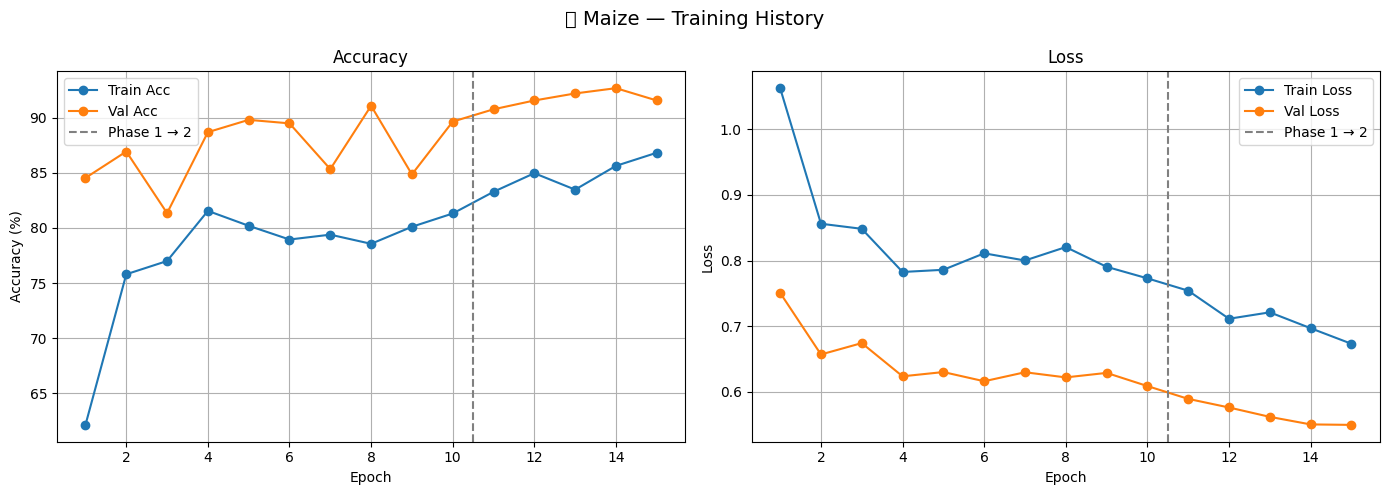

✅ Training plot saved


In [9]:
# ── Cell 9: Training Plot ─────────────────────────────────────
all_epochs = list(range(1, len(history["train_acc"]) + 1))
phase1_end = EPOCHS_PHASE1 + 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(all_epochs, [x * 100 for x in history["train_acc"]], label="Train Acc", marker="o")
ax1.plot(all_epochs, [x * 100 for x in history["val_acc"]], label="Val Acc", marker="o")
ax1.axvline(x=phase1_end, color="gray", linestyle="--", label="Phase 1 → 2")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(all_epochs, history["train_loss"], label="Train Loss", marker="o")
ax2.plot(all_epochs, history["val_loss"], label="Val Loss", marker="o")
ax2.axvline(x=phase1_end, color="gray", linestyle="--", label="Phase 1 → 2")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.suptitle("🌽 Maize — Training History", fontsize=14)
plt.tight_layout()
plt.savefig("maize_training_plot.png", dpi=150)
plt.show()
print("✅ Training plot saved")

## Cell 10: Test Evaluation + Confusion Matrix

**What:** Evaluate the trained model on the test set and build a confusion matrix.

**Why:** We measure final performance and see which classes are being confused.

**Cons:** Test metrics summarize outcomes but do not explain the visual reason behind mistakes.


📊 Classification Report:

                precision    recall  f1-score   support

        Blight       0.92      0.92      0.92       171
   Common_Rust       1.00      0.92      0.96       203
Gray_Leaf_Spot       0.80      0.93      0.86        94
       Healthy       0.99      1.00      1.00       161

      accuracy                           0.94       629
     macro avg       0.93      0.94      0.93       629
  weighted avg       0.95      0.94      0.94       629



/tmp/ipykernel_17782/4259318715.py:31: UserWarning: Glyph 127805 (\N{EAR OF MAIZE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17782/4259318715.py:32: UserWarning: Glyph 127805 (\N{EAR OF MAIZE}) missing from font(s) DejaVu Sans.
  plt.savefig("maize_confusion_matrix.png", dpi=150)
/home/ares/miniconda3/envs/ml-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127805 (\N{EAR OF MAIZE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


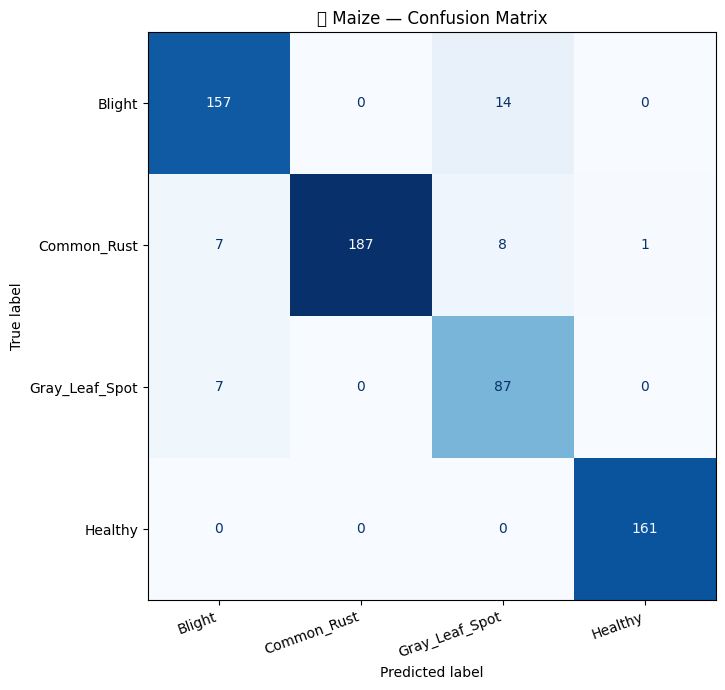

✅ Confusion matrix saved | TTA=ON


In [10]:
# ── Cell 10: Test Evaluation + Confusion Matrix ───────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        if ENABLE_TTA:
            outputs = _tta_logits(model, images)
        else:
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=class_names,
    ax=ax,
    colorbar=False,
    cmap="Blues"
)
ax.set_title("🌽 Maize — Confusion Matrix")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("maize_confusion_matrix.png", dpi=150)
plt.show()
print(f"✅ Confusion matrix saved | TTA={'ON' if ENABLE_TTA else 'OFF'}")

## Cell 11: Explainability and Spread Analysis

## Cell

**What:** Add leaf segmentation, Grad-CAM, and spread estimation utilities.

**Why:** These steps make predictions more interpretable and estimate how much of the leaf is affected.

**Cons:** Image-processing heuristics can be sensitive to lighting, background, and leaf orientation.


In [11]:
import cv2
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
from torchcam.methods import GradCAMpp

# -------------------------------------------------------------
# LAYER 1: Leaf Segmentation - GrabCut + HSV fallback chain
# -------------------------------------------------------------
def segment_leaf(image_np):
    h, w = image_np.shape[:2]
    hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)

    masks = [
        cv2.inRange(hsv, np.array([15, 20, 20]), np.array([95, 255, 255])),
        cv2.inRange(hsv, np.array([5, 30, 30]), np.array([25, 255, 200])),
        cv2.inRange(hsv, np.array([0, 0, 20]), np.array([180, 60, 80])),
    ]
    loose_mask = masks[0]
    for m in masks[1:]:
        loose_mask = cv2.bitwise_or(loose_mask, m)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    loose_mask = cv2.morphologyEx(loose_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    loose_mask = cv2.morphologyEx(loose_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    contours, _ = cv2.findContours(loose_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    seg_path = "adaptive"
    if contours and cv2.contourArea(max(contours, key=cv2.contourArea)) > 0.20 * h * w:
        x, y, bw, bh = cv2.boundingRect(max(contours, key=cv2.contourArea))
        pad = 10
        x = max(0, x - pad)
        y = max(0, y - pad)
        bw = min(w - x, bw + 2 * pad)
        bh = min(h - y, bh + 2 * pad)
        rect = (x, y, bw, bh)
    else:
        rect = (28, 28, 168, 168)
        seg_path = "fixed_center"

    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    mask_gc = np.zeros((h, w), np.uint8)
    try:
        cv2.grabCut(image_np, mask_gc, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
        leaf_mask = np.where((mask_gc == 2) | (mask_gc == 0), 0, 255).astype(np.uint8)
    except Exception:
        leaf_mask = np.full((h, w), 255, np.uint8)
        seg_path = "grabcut_failed"

    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=3)

    if (leaf_mask > 0).sum() < 0.10 * h * w:
        leaf_mask = np.full((h, w), 255, np.uint8)
        seg_path = "full_image_uncertain"

    return (leaf_mask > 0), seg_path


# -------------------------------------------------------------
# LAYER 2: GradCAM++ - dynamic target layer selection
# -------------------------------------------------------------
def _resolve_gradcam_target_layer(model):
    if hasattr(model, "features"):
        for idx in range(len(model.features) - 1, -1, -1):
            block = model.features[idx]
            if any(isinstance(m, torch.nn.Conv2d) for m in block.modules()):
                return f"features.{idx}"

    if hasattr(model, "layer4") and hasattr(model.layer4[-1], "conv2"):
        return "layer4.1.conv2"
    if hasattr(model, "layer4"):
        return "layer4"

    last_conv_name = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv_name = name
    if last_conv_name is not None:
        return last_conv_name

    raise ValueError("No Conv2d layer found for Grad-CAM target layer")


def get_gradcam_mask(model, input_tensor, pred_class):
    target_layer = _resolve_gradcam_target_layer(model)
    cam_extractor = GradCAMpp(model, target_layer=target_layer)
    model.eval()

    image_batch = input_tensor.unsqueeze(0).to(device)
    out = model(image_batch)
    pred_class = int(pred_class)

    try:
        cam_map = cam_extractor(pred_class, out)[0]
    finally:
        cam_extractor.remove_hooks()

    cam_np = cam_map.detach().squeeze().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)
    cam_resized = cv2.resize(cam_np, (224, 224), interpolation=cv2.INTER_LINEAR)
    return cam_resized


# -------------------------------------------------------------
# LAYER 3: Disease Color Detection
# -------------------------------------------------------------
def detect_disease_pixels(image_np):
    # CLAHE improves consistency under variable lighting
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    image_np = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    brown_mask = (h >= 5) & (h <= 25) & (s >= 35) & (v >= 35) & (v <= 210)
    yellow_mask = (h >= 18) & (h <= 40) & (s >= 30) & (v >= 90) & (v <= 250)
    dark_necrotic_mask = (v <= 85) & (s <= 120)

    disease_mask = brown_mask | yellow_mask | dark_necrotic_mask
    disease_mask = (disease_mask.astype(np.uint8) * 255)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Remove tiny noisy blobs
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(disease_mask, connectivity=8)
    cleaned = np.zeros_like(disease_mask)
    min_area = 12
    for lab_idx in range(1, num_labels):
        area = stats[lab_idx, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == lab_idx] = 255

    return cleaned > 0


# -------------------------------------------------------------
# FULL PIPELINE
# -------------------------------------------------------------
def calculate_accurate_spread(model, image_path, class_names, val_transform):
    original_pil = Image.open(image_path).convert("RGB")
    original_pil = original_pil.resize((224, 224))
    image_np = np.array(original_pil)

    input_tensor = val_transform(original_pil)
    model.eval()
    with torch.no_grad():
        out = model(input_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)[0]
    pred_class = probs.argmax().item()
    confidence = probs[pred_class].item() * 100
    disease = class_names[pred_class]
    tier = "High" if confidence >= 85 else "Moderate" if confidence >= 70 else "Low"

    if "healthy" in disease.lower():
        print(f"Disease: {disease} | Confidence: {confidence:.1f}% ({tier})\nSpread: N/A (Healthy plant)")
        return disease, confidence, None, None

    leaf_mask_bin, seg_path = segment_leaf(image_np)
    total_leaf_pixels = int(leaf_mask_bin.sum())

    # Use inner leaf area to reduce border artifacts
    erode_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    leaf_core = cv2.erode((leaf_mask_bin.astype(np.uint8) * 255), erode_kernel, iterations=1) > 0
    if leaf_core.sum() < 0.5 * total_leaf_pixels:
        leaf_core = leaf_mask_bin

    cam = get_gradcam_mask(model, input_tensor, pred_class)
    cam_threshold = float(np.percentile(cam, 75))
    cam_bin = cam >= cam_threshold

    gradcam_coverage = cam_bin.sum() / total_leaf_pixels if total_leaf_pixels > 0 else 0.0
    if gradcam_coverage < 0.01:
        print("Warning: Grad-CAM ROI too small; spread estimate may be unreliable")

    disease_color_mask = detect_disease_pixels(image_np)
    disease_color_mask = disease_color_mask & leaf_core

    combined_mask = leaf_core & cam_bin & disease_color_mask
    diseased_pixels = int(combined_mask.sum())
    spread_percent = (diseased_pixels / total_leaf_pixels) * 100 if total_leaf_pixels > 0 else 0.0

    severity = (
        "Early Stage" if spread_percent < 15 else
        "Moderate" if spread_percent < 40 else "Severe"
    )
    action = (
        "Disease just starting. Apply targeted treatment now." if spread_percent < 15 else
        "Significant spread. Apply fungicide immediately." if spread_percent < 40 else
        "Heavy infection. Isolate crop, consult agronomist."
    )

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(leaf_mask_bin, cmap="Greens")
    axes[1].set_title(f"Leaf Mask ({seg_path})\n{total_leaf_pixels}px")
    axes[1].axis("off")

    axes[2].imshow(cam, cmap="jet")
    axes[2].set_title("GradCAM++ Region")
    axes[2].axis("off")

    axes[3].imshow(disease_color_mask, cmap="Reds")
    axes[3].set_title("Disease Color Pixels")
    axes[3].axis("off")

    overlay = image_np.copy()
    overlay[combined_mask] = [255, 0, 0]
    healthy_leaf = leaf_mask_bin & (~combined_mask)
    overlay[healthy_leaf] = (
        overlay[healthy_leaf] * 0.7 + np.array([0, 200, 0]) * 0.3
    ).astype(np.uint8)

    axes[4].imshow(overlay)
    axes[4].set_title(f"Final: {spread_percent:.1f}% Diseased")
    axes[4].axis("off")

    plt.suptitle(
        f"{disease} | Confidence: {confidence:.1f}% ({tier})\n"
        f"Spread: {spread_percent:.1f}% | {severity}\n{action}\n"
        f"Seg path: {seg_path}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(f"{disease}_spread_analysis.png", dpi=150)
    plt.show()

    print(f"\n{'='*45}")
    print(f"Disease    : {disease}")
    print(f"Confidence : {confidence:.1f}% ({tier})")
    print(f"Seg path   : {seg_path}")
    print(f"Leaf pixels: {total_leaf_pixels}")
    print(f"Diseased px: {diseased_pixels}")
    print(f"Spread     : {spread_percent:.1f}%")
    print(f"Severity   : {severity}")
    print(f"Action     : {action}")
    print(f"{'='*45}")

    return disease, confidence, spread_percent, severity


def gradcam_pytorch(model, img_tensor, device):
    model.eval()
    img_tensor = img_tensor.to(device)
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0))
        pred_class = out.argmax(dim=1).item()
        confidence = torch.softmax(out, dim=1)[0][pred_class].item() * 100

    cam = get_gradcam_mask(model, img_tensor, pred_class)
    spread = np.sum(cam > 0.5) / cam.size * 100
    return cam, pred_class, confidence, spread


def overlay_heatmap(img_path, cam):
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    img = np.array(img)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.6 * img + 0.4 * heatmap).astype(np.uint8)
    return img, overlay


print("Grad-CAM++ and masking pipeline ready")
print("gradcam_pytorch() ready")
print("overlay_heatmap() ready")

Grad-CAM++ and masking pipeline ready
gradcam_pytorch() ready
overlay_heatmap() ready


## Cell 12: Predict

**What:** Define the final maize prediction function and print the disease summary.

**Why:** This wraps the full pipeline into a reusable inference step for new images.

**Cons:** End-to-end predictions depend on all earlier components behaving consistently.


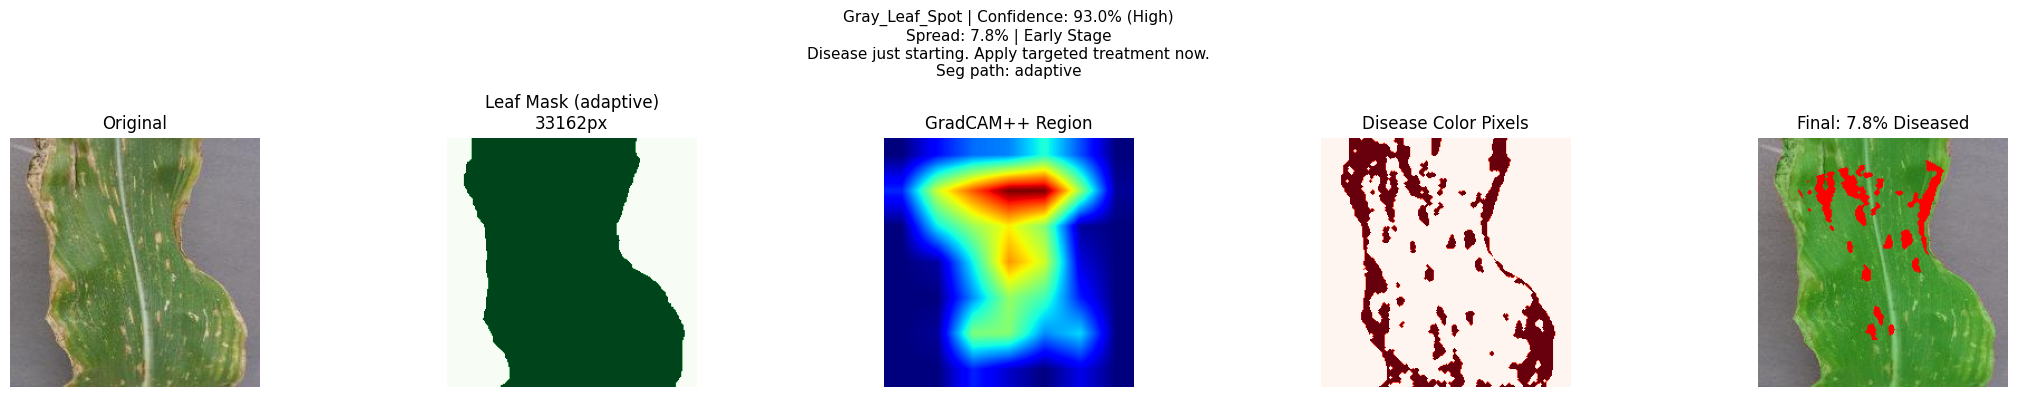


Disease    : Gray_Leaf_Spot
Confidence : 93.0% (High)
Seg path   : adaptive
Leaf pixels: 33162
Diseased px: 2595
Spread     : 7.8%
Severity   : Early Stage
Action     : Disease just starting. Apply targeted treatment now.

🌽 Crop      : Maize
🦠 Disease   : Gray_Leaf_Spot
📊 Confidence: 93.0%
🔥 Spread    : 7.8% | Early Stage


('Gray_Leaf_Spot', 92.95761585235596, 7.82522163922562)

In [12]:
# ── Cell 12: Predict ──────────────────────────────────────────
def predict(img_path, model, class_names, device):
    disease, confidence, spread, severity = calculate_accurate_spread(
        model=model,
        image_path=img_path,
        class_names=class_names,
        val_transform=val_transform,
    )

    print(f"\n🌽 Crop      : Maize")
    print(f"🦠 Disease   : {disease}")
    print(f"📊 Confidence: {confidence:.1f}%")
    if spread is None:
        print("🔥 Spread    : N/A (Healthy plant)")
    else:
        print(f"🔥 Spread    : {spread:.1f}% | {severity}")

    return disease, confidence, spread


# ── Test it ───────────────────────────────────────────────────
TEST_IMAGE = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/maize/Gray_Leaf_Spot/Corn_Gray_Spot_(71).JPG"  # change this
predict(TEST_IMAGE, model, class_names, device)